***Procesamiento avanzado de datos***

**José Roberto Torres López**


*Importacion de librerias, funciones y carga de datos*

In [7]:
#Importación de librerias
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1. Cargar los datos
df = pd.read_csv("../train (1).csv")

# 2. Limpieza básica (Los modelos de Machine Learning no toleran valores vacíos o NaN)
# Llenamos las edades vacías con la mediana de las edades
df['Age'] = df['Age'].fillna(df['Age'].median())
# Llenamos los puertos de embarque vacíos con el más común
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 3. Convertir texto a números
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# Seleccionamos las características que usaremos para predecir
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
X = df[features]
y = df['Survived'] # Esta es nuestra variable objetivo (lo que queremos predecir)

print("Datos preparados y listos.")

Datos preparados y listos.


*Separación de los datos en 70% train, 15% evaluación y 15% prueba*

In [2]:
# Para lograr un 70/15/15, lo hacemos en dos pasos:

# Paso A: Separar el 70% para entrenamiento y el 30% restante para (validación + prueba)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)

# Paso B: Del 30% restante, separamos la mitad (50%) para validación y la otra mitad para prueba. 
# 50% de 30% = 15% del total original.
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f"Total de datos: {len(X)}")
print(f"Datos de Entrenamiento (70%): {len(X_train)}")
print(f"Datos de Evaluación/Validación (15%): {len(X_val)}")
print(f"Datos de Prueba/Test (15%): {len(X_test)}")

Total de datos: 891
Datos de Entrenamiento (70%): 623
Datos de Evaluación/Validación (15%): 134
Datos de Prueba/Test (15%): 134


*Escalamiento de las columnas Age, Fare y SibSp usando StandardScaler y MinMaxScaler*

In [3]:
columnas_a_escalar = ['Age', 'Fare', 'SibSp']

# --- A. Sin Escalar ---
# Ya los tenemos en X_train, X_val, X_test

# --- B. StandardScaler ---
scaler_std = StandardScaler()
X_train_std = X_train.copy()
X_val_std = X_val.copy()
X_test_std = X_test.copy()

X_train_std[columnas_a_escalar] = scaler_std.fit_transform(X_train[columnas_a_escalar])
X_val_std[columnas_a_escalar] = scaler_std.transform(X_val[columnas_a_escalar])
X_test_std[columnas_a_escalar] = scaler_std.transform(X_test[columnas_a_escalar])

# --- C. MinMaxScaler ---
scaler_minmax = MinMaxScaler()
X_train_mm = X_train.copy()
X_val_mm = X_val.copy()
X_test_mm = X_test.copy()

X_train_mm[columnas_a_escalar] = scaler_minmax.fit_transform(X_train[columnas_a_escalar])
X_val_mm[columnas_a_escalar] = scaler_minmax.transform(X_val[columnas_a_escalar])
X_test_mm[columnas_a_escalar] = scaler_minmax.transform(X_test[columnas_a_escalar])

print("Datos escalados con éxito en sus respectivas versiones.")

Datos escalados con éxito en sus respectivas versiones.


*Entrenamiento de los modelos (arboles de desición y knn) junto a la evaluacion con cada grupo de datos (escalados y no escalados)*

In [4]:
# Definimos una función para entrenar y evaluar fácilmente y no repetir código
def evaluar_modelo(modelo, X_t, y_t, X_v, y_v, nombre_datos):
    modelo.fit(X_t, y_t) # El modelo aprende con los datos de entrenamiento
    predicciones = modelo.predict(X_v) # El modelo se pone a prueba con validación
    precision = accuracy_score(y_v, predicciones)
    print(f"Precisión con {nombre_datos}: {precision * 100:.2f}%")

# 1. Instanciamos los modelos
# Fijamos random_state en el Árbol para que los resultados sean consistentes
arbol = DecisionTreeClassifier(random_state=42) 
knn = KNeighborsClassifier(n_neighbors=5)

print("--- RESULTADOS ÁRBOL DE DECISIÓN ---")
# Teoría: Deberían dar resultados idénticos o casi idénticos, porque al árbol no le afectan las escalas.
evaluar_modelo(arbol, X_train, y_train, X_val, y_val, "Datos Originales")
evaluar_modelo(arbol, X_train_std, y_train, X_val_std, y_val, "StandardScaler")
evaluar_modelo(arbol, X_train_mm, y_train, X_val_mm, y_val, "MinMaxScaler")

print("\n--- RESULTADOS K-NEIGHBORS (KNN) ---")
# Teoría: Los datos escalados deberían tener un mejor rendimiento que los originales.
evaluar_modelo(knn, X_train, y_train, X_val, y_val, "Datos Originales")
evaluar_modelo(knn, X_train_std, y_train, X_val_std, y_val, "StandardScaler")
evaluar_modelo(knn, X_train_mm, y_train, X_val_mm, y_val, "MinMaxScaler")

--- RESULTADOS ÁRBOL DE DECISIÓN ---
Precisión con Datos Originales: 77.61%
Precisión con StandardScaler: 78.36%
Precisión con MinMaxScaler: 77.61%

--- RESULTADOS K-NEIGHBORS (KNN) ---
Precisión con Datos Originales: 69.40%
Precisión con StandardScaler: 80.60%
Precisión con MinMaxScaler: 80.60%


*Visualizacion de los datos*

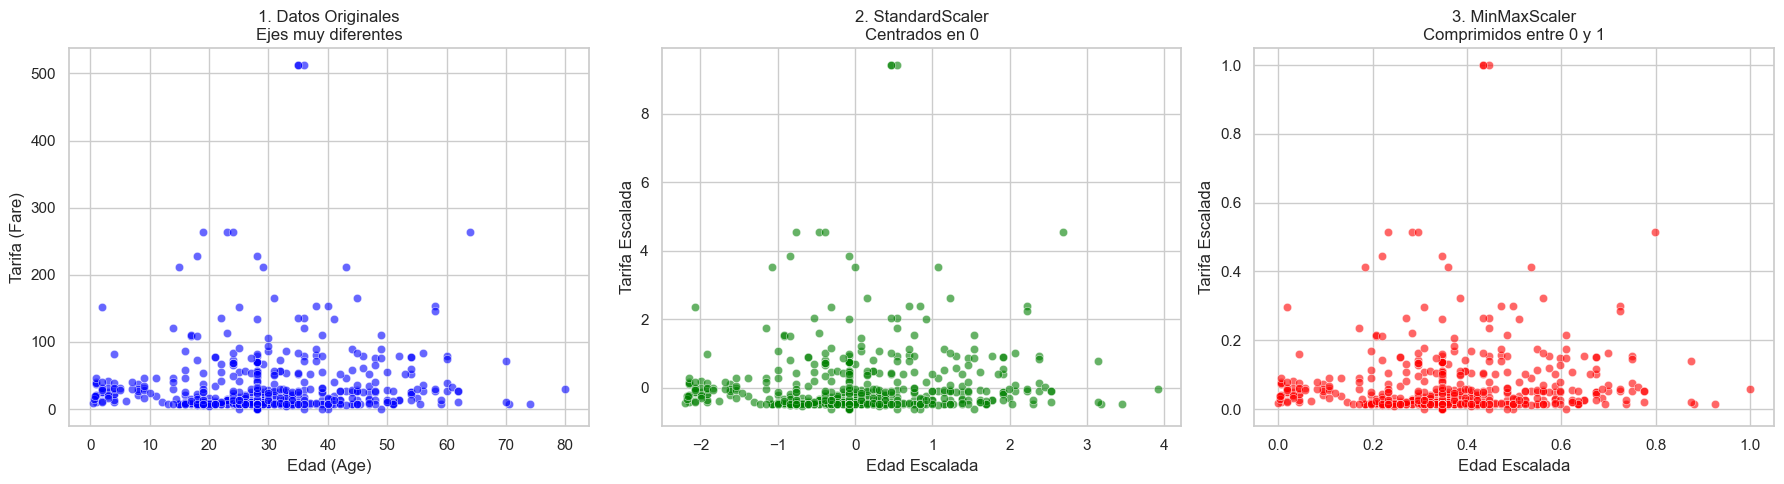

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Gráfico de Datos Originales
sns.scatterplot(x=X_train['Age'], y=X_train['Fare'], ax=axes[0], color='blue', alpha=0.6)
axes[0].set_title("1. Datos Originales\nEjes muy diferentes")
axes[0].set_xlabel("Edad (Age)")
axes[0].set_ylabel("Tarifa (Fare)")

# 2. Gráfico con StandardScaler
sns.scatterplot(x=X_train_std['Age'], y=X_train_std['Fare'], ax=axes[1], color='green', alpha=0.6)
axes[1].set_title("2. StandardScaler\nCentrados en 0")
axes[1].set_xlabel("Edad Escalada")
axes[1].set_ylabel("Tarifa Escalada")

# 3. Gráfico con MinMaxScaler
sns.scatterplot(x=X_train_mm['Age'], y=X_train_mm['Fare'], ax=axes[2], color='red', alpha=0.6)
axes[2].set_title("3. MinMaxScaler\nComprimidos entre 0 y 1")
axes[2].set_xlabel("Edad Escalada")
axes[2].set_ylabel("Tarifa Escalada")

plt.tight_layout()
plt.show()

*Visualizacion de los datos en 3*

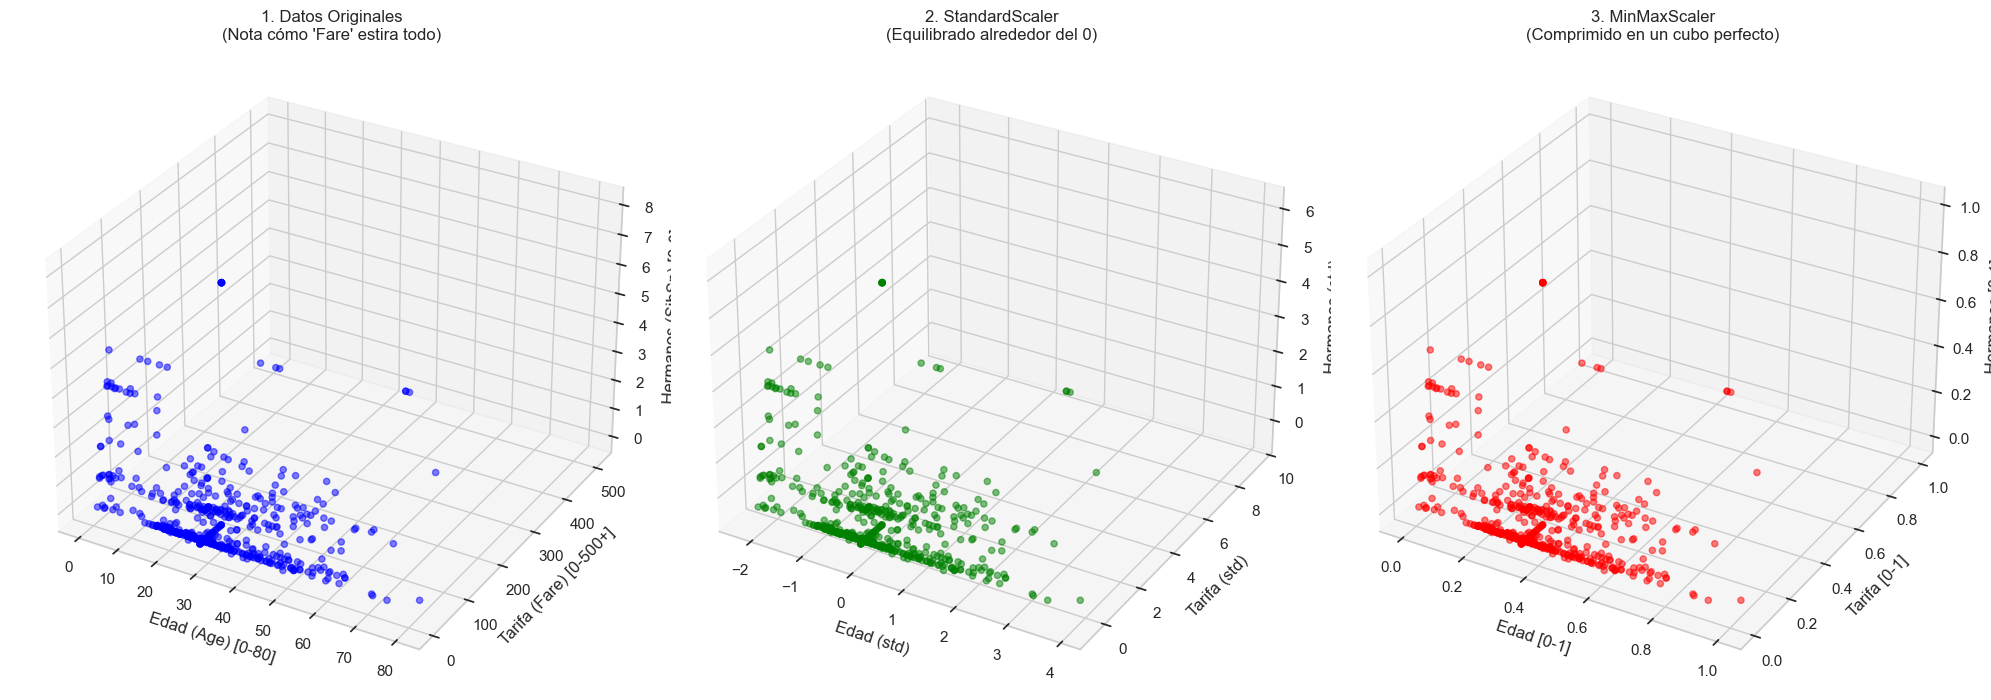

In [8]:
import matplotlib.pyplot as plt

# Configuramos la figura para 3 gráficos en 3D
fig = plt.figure(figsize=(20, 7))

# --- 1. Gráfico 3D: Datos Originales ---
ax1 = fig.add_subplot(1, 3, 1, projection='3d')
ax1.scatter(X_train['Age'], X_train['Fare'], X_train['SibSp'], c='blue', alpha=0.5)
ax1.set_title("1. Datos Originales\n(Nota cómo 'Fare' estira todo)")
ax1.set_xlabel("Edad (Age) [0-80]")
ax1.set_ylabel("Tarifa (Fare) [0-500+]")
ax1.set_zlabel("Hermanos (SibSp) [0-8]")

# --- 2. Gráfico 3D: StandardScaler ---
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
ax2.scatter(X_train_std['Age'], X_train_std['Fare'], X_train_std['SibSp'], c='green', alpha=0.5)
ax2.set_title("2. StandardScaler\n(Equilibrado alrededor del 0)")
ax2.set_xlabel("Edad (std)")
ax2.set_ylabel("Tarifa (std)")
ax2.set_zlabel("Hermanos (std)")

# --- 3. Gráfico 3D: MinMaxScaler ---
ax3 = fig.add_subplot(1, 3, 3, projection='3d')
ax3.scatter(X_train_mm['Age'], X_train_mm['Fare'], X_train_mm['SibSp'], c='red', alpha=0.5)
ax3.set_title("3. MinMaxScaler\n(Comprimido en un cubo perfecto)")
ax3.set_xlabel("Edad [0-1]")
ax3.set_ylabel("Tarifa [0-1]")
ax3.set_zlabel("Hermanos [0-1]")

plt.tight_layout()
plt.show()

**Conclusiónes personales**

La escalabilidad de los datos ayuda fuertemente a tener un mejor modelo, hay que recordar que los datos son la base de cualquier modelo y si hay un desequilibrio se suele nota demasiado a la hora del modelado. No obstante, considero que depende el proceso y el modelo usando posiblemente no haya mucha diferencia, como paso con los árboles de decisión, donde s noto apenas una diferencia del 2% aproximadamente. 

Por otra parte, las gráficas ayudan a visualizar que los datos se normalizan un poco más hacia el cero, haciendo más "compactos" ayudando a entenderlos y, sobre todo, a la hora del modelaje tener una mejor precisión. 

Definitivamente el procesamiento de los datos es bastante útil al momento de querer modelarlos.